In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import dotenv
import os

config = dotenv.dotenv_values(".env")
replace_keys = ["JAVA_HOME", "FUSEKI_HOME"]
append_keys = ["PATH"]
for key, value in config.items():
    # append to os.environ
    if key in append_keys:
        os.environ[key] = f"{os.environ.get(key, '')}:{value}"
    elif key in replace_keys:
        os.environ[key] = value

# check and compare values in fuseki log
os.environ["OPENBLAS_NUM_THREADS"] = "4"

In [5]:
sys.path.append(".")

In [6]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs.qlever import QleverDB
from utils.dbs.fuseki import FusekiDB
from utils.dbs.base_db import BaseDB
from utils.dbs.qlever_native import QleverDBNative
from utils.dbs.fuseki_native import FusekiDBNative
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

In [7]:
powers = np.arange(0, 5)  # extend on a more powerful machine
sizes = 10**powers

In [8]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    # raw_sizes[power] = dataset.get_triple_count()

2026-04-16 10:04:32,507 - INFO - BSBM dataset already exists in data/bsbm_0, skipping generation
2026-04-16 10:04:32,508 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-04-16 10:04:32,508 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-04-16 10:04:32,509 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation
2026-04-16 10:04:32,509 - INFO - BSBM dataset already exists in data/bsbm_4, skipping generation


Running BDSDM generation for size 1...
Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...
Running BDSDM generation for size 10000...


In [9]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    encoded_sizes[power] = dataset.encode_streaming(encoding_model)
    #  dataset.get_triple_count(encoded=True)

Encoding dataset of size 1...
Encoded TTL file already exists at data/bsbm_0/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10000...
Encoded TTL file already exists at data/bsbm_4/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [10]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.058949727565050125, -0.0051073553040623665, 0.09506019204854965, -0.029170090332627296, -0.07172352075576782, 0.036426812410354614, 0.01788988709449768, 0.07774496078491211, -0.01058284193277359, -0.02719942107796669, -0.014839782379567623, 0.004996407311409712, -0.05195301026105881, -0.01563340425491333, -0.0004883587826043367, 0.012572054751217365, -0.043

In [12]:
base_bsbm_set = datasets[2]
db = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
db_no_tensor_idx = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
    enable_tensor_index=False,
)
db_fuseki = FusekiDBNative(
    id="test_fuseki",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
possible_queries = db.get_queries(test_tensor)
print(possible_queries)


2026-04-16 10:04:34,153 - INFO - Initialized QLeverDBNative with id=test, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/test-with-tidx/sparql
2026-04-16 10:04:34,154 - INFO - Initialized QLeverDBNative with id=test, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/test-no-tidx/sparql


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>\nPREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nPREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>\nSELECT ?product  ?vector ?dist\nWHERE {\n?product rdf:label_embedding ?vector .\nBIND(dtf:cosineSimilarity(?vector, "{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.084

In [13]:
print(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])


PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
SELECT ?product  ?vector ?dist
WHERE {
?product rdf:label_embedding ?vector .
BIND(dtf:cosineSimilarity(?vector, "{\"data\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.05894972756505012

In [14]:
import os
os.getcwd()

'/nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks'

In [15]:
import time

with db:
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        noised_tensor = test_tensor.to_numpy() + np.random.normal(scale=0.01, size=test_tensor.to_numpy().shape)
        noised_tensor = DataTensor.from_numpy(noised_tensor)

        results = db.query_auto(
            noised_tensor,
            query_difficulty=QUERY_DIFFICULTY.EASY,
            query_type=QUERY_TYPE.EMBEDDED,
        )
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-04-16 10:04:34,346 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 10:04:34,348 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt -i test-with-tidx --vocabulary-type on-disk-compressed-tensor-split
2026-04-16 10:04:35,507 - INFO - Stopping server!
2026-04-16 10:04:35,508 - INFO - Starting QLever server on port 8031
2026-04-16 10:04:35,508 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 10:04:35,519 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)
2026-04-16 10:04:36,691 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:02<00:00,  3.55it/s]
2026-04-16 10:04:39,525 - INFO - Stopping server!


Median elapsed time: 0.27468180656433105


,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",0.3150379657745
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",0.3115608096123
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2873241603374
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",0.2860917448997
4,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2565962076187
5,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2523704171181
6,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2503345310688
7,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2490429133177
8,bsbmi:ProductFeature66,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2487554252148
9,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",0.2456527799368


In [17]:
with db:
    possible_queries = db.get_queries(test_tensor)
    results = db.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.INDEX])
results

2026-04-16 10:05:32,391 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 10:05:32,738 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-with-tidx already exists!
2026-04-16 10:05:32,814 - INFO - Stopping server!
2026-04-16 10:05:32,865 - INFO - Starting QLever server on port 8031
2026-04-16 10:05:32,882 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 10:05:33,025 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)
2026-04-16 10:05:34,191 - INFO - Server is up and responding to queries
2026-04-16 10:05:36,082 - INFO - Stopping server!


,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",1.366928339005
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",1.412792205811
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",1.426476240158
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",1.440332531929
4,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",1.471283555031
5,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",1.472614526749
6,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",1.479606389999
7,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",1.481603384018
8,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",1.518724322319
9,bsbmi:ProductFeature66,"{""data"": [0.07709012180566788, 0.0770644396543...",1.51947927475


In [49]:
with db_fuseki:
    possible_queries = db_fuseki.get_queries(test_tensor)
    results = db_fuseki.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-16 09:59:33,893 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt
2026-04-16 09:59:33,894 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test_fuseki already exists, removing locks if any
2026-04-16 09:59:33,895 - INFO - Stopping server!
2026-04-16 09:59:33,896 - INFO - Starting Fuseki server port 7031
2026-04-16 09:59:33,896 - WARNING - Server is already running, stopping it first
2026-04-16 09:59:33,896 - INFO - Stopping server!
2026-04-16 09:59:33,897 - ERROR - TENSOR_CP environment variable is not set
2026-04-16 09:59:33,898 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-16 09:59:33,898 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-16 09:59:33,898 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-16 09:59:33,899 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-da

,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",0.31653597950935364
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",0.29360419511795044
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163147
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798336446285248
4,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",0.26435840129852295
5,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2636927366256714
6,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",0.26019686460494995
7,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.25919830799102783
8,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",0.24063780903816223
9,bsbmi:ProductFeature66,"{""data"": [0.07709012180566788, 0.0770644396543...",0.24026034772396088


In [19]:
with db_no_tensor_idx:
    possible_queries = db_no_tensor_idx.get_queries(test_tensor)
    results = db_no_tensor_idx.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-16 09:34:14,757 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 09:34:14,758 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt -i test-no-tidx
2026-04-16 09:34:16,343 - INFO - Stopping server!
2026-04-16 09:34:16,343 - INFO - Starting QLever server on port 8031
2026-04-16 09:34:16,345 - INFO - Running command: qlever-server -i test-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 09:34:16,347 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-no-tidx/sparql)
2026-04-16 09:34:17,360 - INFO - Server is up and responding to queries
2026-04-16 09:34:17,447 - INFO - Stopping server!


,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",0.3165358603001
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",0.2936039566994
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798337340355
4,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",0.2643582224846
5,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",0.263692855835
6,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2601968050003
7,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2591982781887
8,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2406378388405
9,bsbmi:ProductFeature66,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2402603030205


In [20]:
import os
os.environ["PATH"]

'/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/qlever/build/release:/home/kantz/apache-jena-fuseki-5.2.0:/home/kantz/apache-jena-5.2.0/bin:/home/kantz/miniconda3/envs/qlever/bin:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/kantz/.vscode-server/cli/servers/Stable-cfbea10c5ffb233ea9177d34726e6056e89913dc/server/bin/remote-cli:/home/kantz/bin:/home/kantz/bin:/home/kantz/.local/bin:/usr/share/Modules/bin:/usr/condabin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/home/kantz/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts:/home/kantz/.vscode-server/cli/servers/Stabl

In [21]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-04-16 09:34:17,582 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 09:34:17,583 - INFO - Indexing dataset with QLever indexer, this may take a while; arguments: -f /nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks/data/bsbm_2/dataset_encoded.nt -i test-with-tidx --vocabulary-type on-disk-compressed-tensor-split
2026-04-16 09:34:18,789 - INFO - Stopping server!
2026-04-16 09:34:18,790 - INFO - Starting QLever server on port 8031
2026-04-16 09:34:18,790 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 09:34:18,793 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)
2026-04-16 09:34:19,808 - INFO - Server is up and responding to queries
2026-04-16 09:34:19,819 - INFO - Stopping server!


   count
0  42417


## Try some timings!

In [18]:
from dataclasses import dataclass
import timeit
import pandas as pd

from utils.dbs.base_docker import BaseDocker
from sklearn.metrics import ndcg_score


@dataclass
class TestResult:
    timings: pd.DataFrame
    stats: pd.DataFrame


def test_db(
    power: int,
    size: int,
    db: BaseDocker,
    difficulty=QUERY_DIFFICULTY.EASY,
    query_type=QUERY_TYPE.EMBEDDED,
    repetitions=128,
    reference_results: pd.DataFrame = None,
) -> TestResult:
    timings = []
    if query_type not in db.get_available_query_types():
        print(f"Query type {query_type} not available for {db.name}, skipping.")
        return TestResult(timings=pd.DataFrame(), stats=pd.DataFrame())
    db.start_record_stats()
    for i in tqdm.tqdm(
        range(repetitions),
        desc=f"Timing for size {size}, difficulty {difficulty.value}, query type {query_type.value}, db {db.name}",
    ):
        # add a small amount of noise to the test tensor to avoid caching effects
        noised_tensor = DataTensor.from_numpy(
            test_tensor.data + np.random.normal(scale=0.001, size=test_tensor.shape)
        )

        test_queries = db.get_queries(embedding=noised_tensor)
        q = test_queries[difficulty][query_type]
        start_time = timeit.default_timer()
        end_time = None
        score = -1
        try:
            results = db.raw_query(q)
            # score the results if reference results are provided
            end_time = timeit.default_timer()
            results_df = db.q_to_df_values(results)
            if reference_results is not None:
                # compute ndcg
                reference_scores = np.ones(len(reference_results))
                result_scores = np.zeros(len(results_df))
                # set to one if in the reference results
                for i, row in results_df.iterrows():
                    if results_df.iloc[i, 0] in reference_results.iloc[:, 0].values:
                        result_scores[i] = 1
                score = ndcg_score([reference_scores], [result_scores])
            assert results is not None and len(results.bindings) > 0, (
                "Query returned no results"
            )
        except Exception as e:
            print(f"Error occurred while querying {db.name}: {e}")
            raise e
        elapsed_time = end_time - start_time if end_time is not None else np.inf
        timings.append(
            {
                "size": encoded_sizes[power],
                "power": power,
                "estimated_size": size,
                "elapsed_time": elapsed_time,
                "rep": i,
                "engine": db.name,
                "difficulty": difficulty.value,
                "query_type": query_type.value,
                "ndcg_score": score,
            }
        )
        if elapsed_time > 30:
            print(
                f"Warning: Query took {elapsed_time:.2f} seconds on {db.name} for size {size}, difficulty {difficulty.value}, query type {query_type.value}. Will cancel."
            )
            break
    db.stop_record_stats()
    stats = db.stat_recorder.get_stats()
    stats["size"] = encoded_sizes[power]
    stats["power"] = power
    stats["difficulty"] = difficulty.value
    stats["query_type"] = query_type.value
    stats["estimated_size"] = size
    stats["engine"] = db.name
    
    db.stat_recorder.clear_stats()

    return TestResult(
        timings=pd.DataFrame(timings),
        stats=stats,
    )


timings_df = pd.DataFrame()
stats_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [
        # QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDocker] = [
        FusekiDBNative(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            enable_tensor_index=True,
            name="Qlever",
        ),
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            enable_tensor_index=False,
            name="Qlever (no Tensor Vocabulary)",
        ),
    ]
    reference_db = dbs[0]
    for difficulty in difficulties:
        with reference_db:
            reference_results = reference_db.query_auto(
                test_tensor,
                query_difficulty=difficulty,
                query_type=QUERY_TYPE.EMBEDDED,
            )
        for db in dbs:
            repetitions = 16 if difficulty == QUERY_DIFFICULTY.EASY else 16
            reference_results: pd.DataFrame = None

            for query_type in [
                QUERY_TYPE.INDEX,
                QUERY_TYPE.EMBEDDED,
            ]:
                print(
                    f"Testing {db.name} with difficulty {difficulty.value} and query type {query_type.value}..."
                )
                with db:
                    db_results = test_db(
                        power=power,
                        size=size,
                        db=db,
                        difficulty=difficulty,
                        query_type=query_type,
                        repetitions=repetitions,
                        reference_results=reference_results,
                    )
                    timings_df = pd.concat(
                        [timings_df, db_results.timings], ignore_index=True
                    )
                    stats_df = pd.concat(
                        [stats_df, db_results.stats], ignore_index=True
                    )


2026-04-16 10:05:43,061 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=Qlever, use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever-with-tidx/sparql
2026-04-16 10:05:43,062 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=Qlever (no Tensor Vocabulary), use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever-no-tidx/sparql
2026-04-16 10:05:43,066 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt
2026-04-16 10:05:43,067 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-fuseki already exists, removing locks if any
2026-04-16 10:05:43,071 - INFO - Stopping server!
2026-04-16 10:05:43,072 - INFO - Starting Fuseki server port 7031
2026-04-16 10:05:43,074 - ERROR - TENSOR_CP environment variable is not set
2026-04-16 10:05:43,076 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-16 10:

Running BDSDM timing for size 1...


2026-04-16 10:05:52,491 - INFO - Server is up and responding to queries
2026-04-16 10:05:56,012 - INFO - Stopping server!
2026-04-16 10:05:56,015 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt
2026-04-16 10:05:56,016 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-fuseki already exists, removing locks if any
2026-04-16 10:05:56,017 - INFO - Stopping server!
2026-04-16 10:05:56,019 - INFO - Starting Fuseki server port 7031
2026-04-16 10:05:56,019 - WARNING - Server is already running, stopping it first
2026-04-16 10:05:56,020 - INFO - Stopping server!
2026-04-16 10:05:56,020 - ERROR - TENSOR_CP environment variable is not set
2026-04-16 10:05:56,022 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-16 10:05:56,022 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-16 10:05:56,023 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-16 10:05:56,024 

Testing FusekiDB + RDFTensor with difficulty easy and query type index...


2026-04-16 10:05:57,074 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-04-16 10:05:58,577 - INFO - Server is up and responding to queries


...

2026-04-16 10:10:50,202 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db Qlever: 100%|██████████| 16/16 [00:35<00:00,  2.24s/it]
2026-04-16 10:11:26,036 - INFO - Stopping server!
2026-04-16 10:11:26,038 - INFO - Loading dataset into QLever server from data/bsbm_4/dataset.nt
2026-04-16 10:11:26,039 - WARNING - DB directory scratch/bsbm/bsbm_4/db/timing-qlever-no-tidx already exists!
2026-04-16 10:11:26,040 - INFO - Stopping server!
2026-04-16 10:11:26,041 - INFO - Starting QLever server on port 8031
2026-04-16 10:11:26,041 - INFO - Running command: qlever-server -i timing-qlever-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 10:11:26,046 - INFO - Waiting for server to start..., got error: [Errno 104] Connection reset by peer (http://localhost:8031/timing-qlever-no-tidx/sparql)


Testing Qlever (no Tensor Vocabulary) with difficulty easy and query type index...


2026-04-16 10:11:27,065 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type index, db Qlever (no Tensor Vocabulary): 100%|██████████| 16/16 [00:02<00:00,  6.61it/s]
2026-04-16 10:11:29,501 - INFO - Stopping server!
2026-04-16 10:11:29,503 - INFO - Loading dataset into QLever server from data/bsbm_4/dataset.nt
2026-04-16 10:11:29,503 - WARNING - DB directory scratch/bsbm/bsbm_4/db/timing-qlever-no-tidx already exists!
2026-04-16 10:11:29,504 - INFO - Stopping server!
2026-04-16 10:11:29,504 - INFO - Starting QLever server on port 8031
2026-04-16 10:11:29,505 - INFO - Running command: qlever-server -i timing-qlever-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 10:11:29,513 - INFO - Waiting for server to start..., got error: [Errno 104] Connection reset by peer (http://localhost:8031/timing-qlever-no-tidx/sparql)


Testing Qlever (no Tensor Vocabulary) with difficulty easy and query type embedded...


2026-04-16 10:11:30,524 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db Qlever (no Tensor Vocabulary): 100%|██████████| 16/16 [00:14<00:00,  1.07it/s]
2026-04-16 10:11:45,436 - INFO - Stopping server!


In [19]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
0,None,0,1,1.006994,0,FusekiDB + RDFTensor,easy,embedded,-1
1,None,0,1,0.093044,1,FusekiDB + RDFTensor,easy,embedded,-1
2,None,0,1,0.067996,2,FusekiDB + RDFTensor,easy,embedded,-1
3,None,0,1,0.299415,3,FusekiDB + RDFTensor,easy,embedded,-1
4,None,0,1,0.723894,4,FusekiDB + RDFTensor,easy,embedded,-1
...,...,...,...,...,...,...,...,...,...
395,None,4,10000,0.944347,11,Qlever (no Tensor Vocabulary),easy,embedded,-1
396,None,4,10000,0.893450,12,Qlever (no Tensor Vocabulary),easy,embedded,-1
397,None,4,10000,0.889525,13,Qlever (no Tensor Vocabulary),easy,embedded,-1
398,None,4,10000,0.952441,14,Qlever (no Tensor Vocabulary),easy,embedded,-1


In [20]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['FusekiDB + RDFTensor', 'Qlever', 'Qlever (no Tensor Vocabulary)']
Length: 3, dtype: str

In [21]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [22]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [23]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'FusekiDB + RDFTensor': 'C0',
 'Qlever': 'C1',
 'Qlever (no Tensor Vocabulary)': 'C2'}

/tmp/ipykernel_3985259/3173237080.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


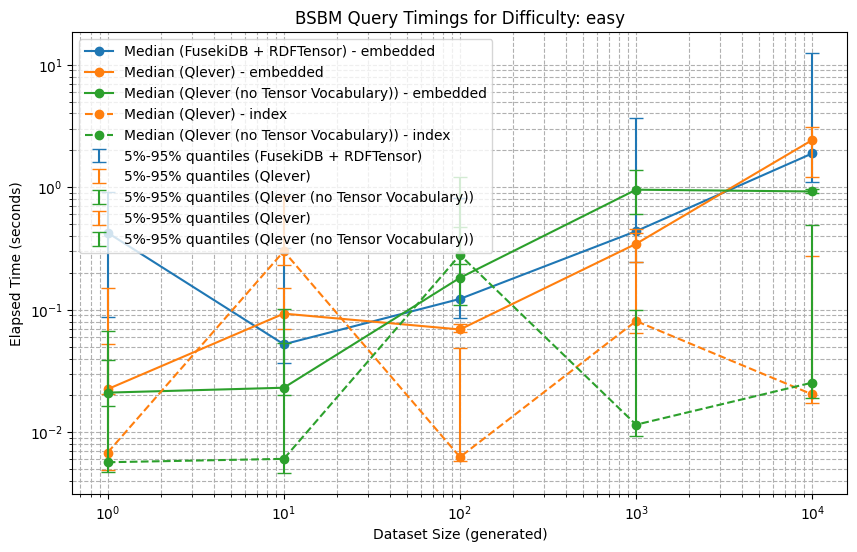

In [24]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, df, engine, difficulty, relevant_measure="elapsed_time"):
    groupings = df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = [0.05, 0.95]
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["estimated_size"],
                engine_median[relevant_measure],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["estimated_size"],
                engine_median[relevant_measure],
                yerr=[
                    engine_median[relevant_measure] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median[relevant_measure],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, timings_df, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (generated)")
    ax.set_ylabel("Elapsed Time (seconds)")
    ax.set_title(f"BSBM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_timings.png")
plt.show()

In [25]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-04-16 10:06:01.277791,0.0,325505024,-1,21722525,1,None,0,easy,embedded,1,FusekiDB + RDFTensor
1,2026-04-16 10:06:02.032887,462.1,376242176,-1,24466788,1,None,0,easy,embedded,1,FusekiDB + RDFTensor
2,2026-04-16 10:06:02.168457,1136.5,384724992,-1,24851041,1,None,0,easy,embedded,1,FusekiDB + RDFTensor
3,2026-04-16 10:06:02.302616,454.7,392429568,-1,25592731,1,None,0,easy,embedded,1,FusekiDB + RDFTensor
4,2026-04-16 10:06:02.436996,364.6,394199040,-1,26521808,1,None,0,easy,embedded,1,FusekiDB + RDFTensor
...,...,...,...,...,...,...,...,...,...,...,...,...
679,2026-04-16 10:11:44.837929,91.1,100843520,-1,1892985193,1,None,4,easy,embedded,10000,Qlever (no Tensor Vocabulary)
680,2026-04-16 10:11:44.957147,100.7,100843520,-1,1909470304,1,None,4,easy,embedded,10000,Qlever (no Tensor Vocabulary)
681,2026-04-16 10:11:45.075893,109.4,100843520,-1,1926274413,1,None,4,easy,embedded,10000,Qlever (no Tensor Vocabulary)
682,2026-04-16 10:11:45.194574,92.7,100843520,-1,1942962936,1,None,4,easy,embedded,10000,Qlever (no Tensor Vocabulary)


In [26]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

/tmp/ipykernel_3985259/3173237080.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


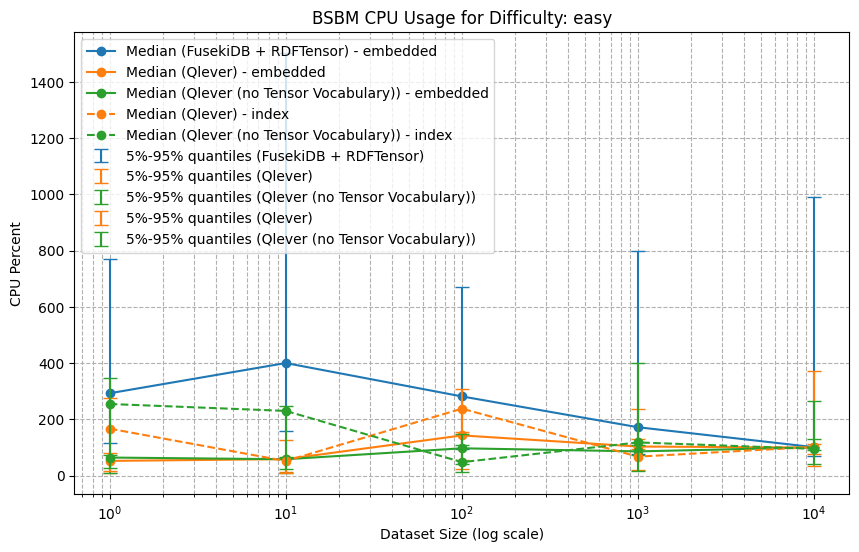

In [27]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="cpu_percent")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("CPU Percent")
    ax.set_title(f"BSBM CPU Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_cpu_usage.png")
plt.show()


/tmp/ipykernel_3985259/3173237080.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


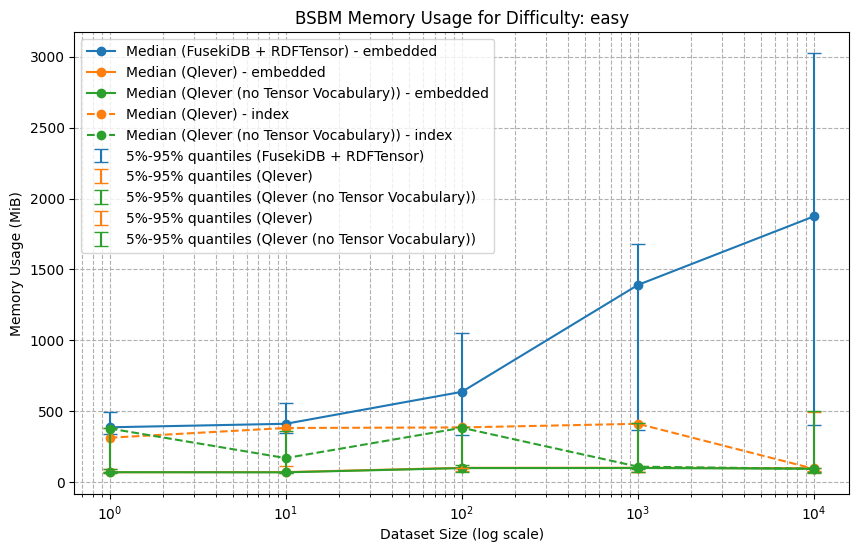

In [28]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="mem_usage_mb")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Memory Usage (MiB)")
    ax.set_title(f"BSBM Memory Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_mem_usage.png")
plt.show()
